In [226]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold

from opfython.models import SupervisedOPF
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid

from imblearn.under_sampling import NearMiss

from scipy.stats import wilcoxon
import scipy.stats as st

In [ ]:
df = pd.read_excel('Online-Retail.xlsx')

In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

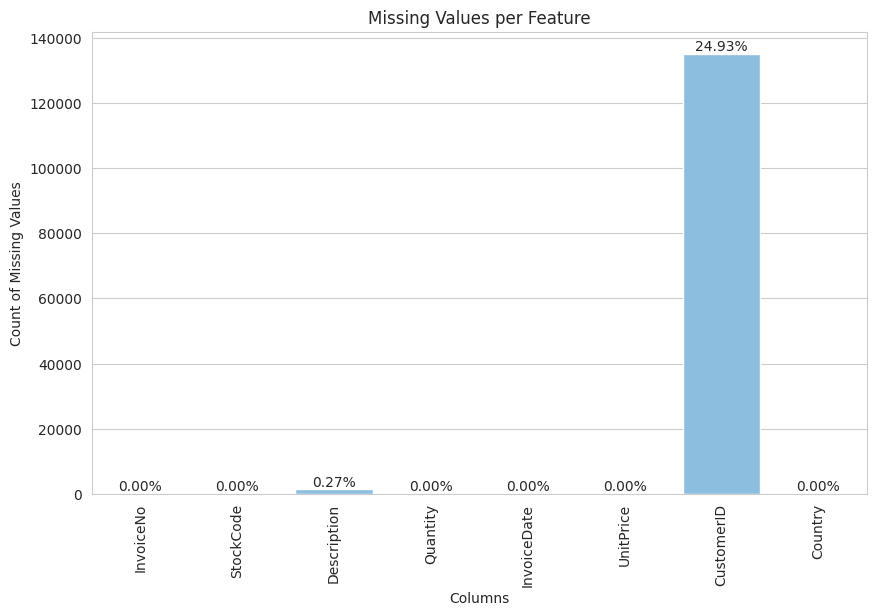

In [ ]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_data = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_percentage})

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_data.index, y=missing_data['Missing Count'], color='#7EC0EE')

for i, v in enumerate(missing_data['Missing Count']):
    plt.text(i, v + 1, f'{missing_data["Missing Percentage"].iloc[i]:.2f}%', ha='center', va='bottom', fontsize=10)

plt.title('Missing Values per Feature')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=90)
plt.show()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [ ]:
df['UnitPrice'] = df['UnitPrice'].astype(str).str.replace(',', '.').astype(float)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [ ]:
df['UnitPrice'].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

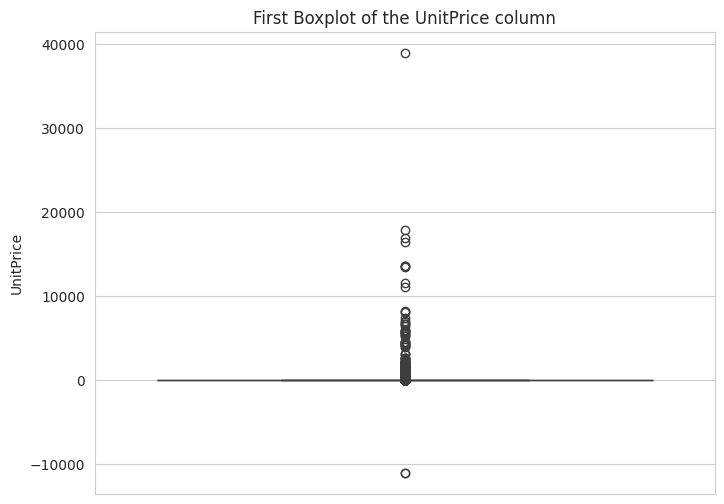

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='UnitPrice', data=df)
plt.title("First Boxplot of the UnitPrice column")
plt.show()

In [ ]:
median = df['UnitPrice'][df['UnitPrice'] >= 0].median()
df['UnitPrice'] = df['UnitPrice'].apply(lambda x: median if x < 0 else x)

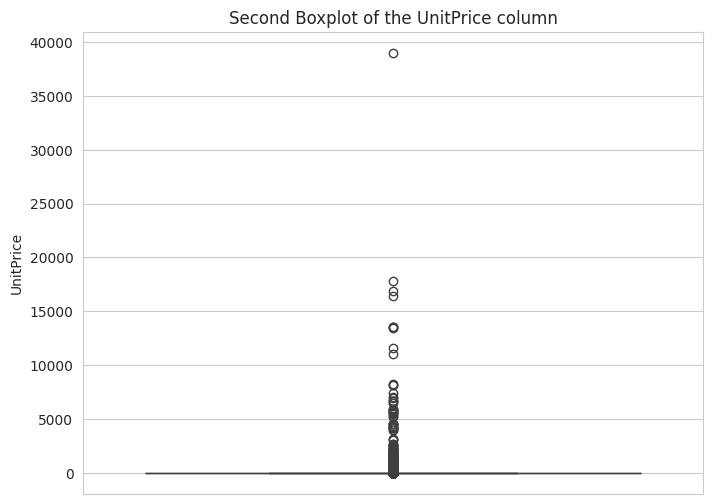

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='UnitPrice', data=df)
plt.title("Second Boxplot of the UnitPrice column")
plt.show()

In [ ]:
df['UnitPrice'].describe()

count    541909.000000
mean          4.651948
std          94.395273
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [ ]:
Q1_UP = df['UnitPrice'].quantile(0.25)
Q2_UP = df['UnitPrice'].quantile(0.5)
Q3_UP = df['UnitPrice'].quantile(0.75)

lower_limit_UP = Q1_UP - 1.5 * (Q3_UP - Q1_UP)
upper_limit_UP = Q3_UP + 1.5 * (Q3_UP - Q1_UP)

print(f"Feature: UnitPrice")
print(f"- Q1: {Q1_UP:.2f}")
print(f"- Q2 (Mediana): {Q2_UP:.2f}")
print(f"- Q3: {Q3_UP:.2f}")
print(f"- Limite Inferior: {lower_limit_UP:.2f}")
print(f"- Limite Superior: {upper_limit_UP:.2f}")

Feature: UnitPrice
- Q1: 1.25
- Q2 (Mediana): 2.08
- Q3: 4.13
- Limite Inferior: -3.07
- Limite Superior: 8.45


In [ ]:
mean_UP = df['UnitPrice'].mean()
median_UP = df['UnitPrice'].median()
mode_UP = df['UnitPrice'].mode()[0]
var_UP = df['UnitPrice'].var()
std_UP = df['UnitPrice'].std()

print(f"Feature: UnitPrice")
print(f"- mean: {mean_UP:.6f}")
print(f"- median: {median_UP:.6f}")
print(f"- mode: {mode_UP:.6f}")
print(f"- var: {var_UP:.6f}")
print(f"- std: {std_UP:.6f}")

Feature: UnitPrice
- mean: 4.651948
- median: 2.080000
- mode: 1.250000
- var: 8910.467515
- std: 94.395273


In [ ]:
df['Quantity'].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

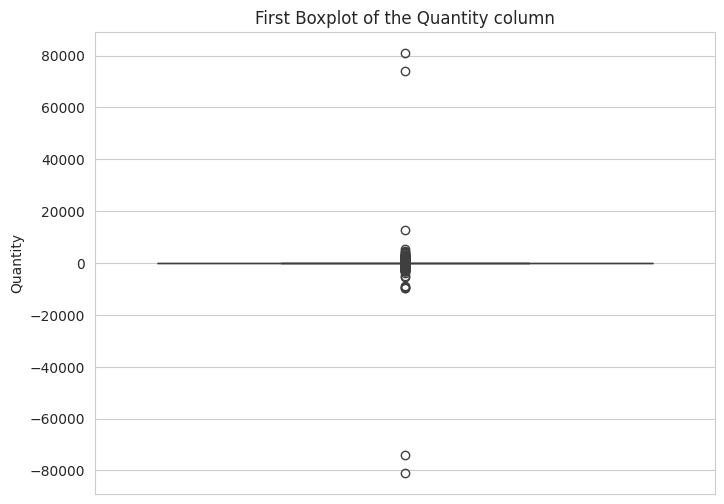

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Quantity', data=df)
plt.title("First Boxplot of the Quantity column")
plt.show()

In [ ]:
median = df['Quantity'][df['Quantity'] > 0].median()
df['Quantity'] = df['Quantity'].apply(lambda x: median if x <= 0 else x)

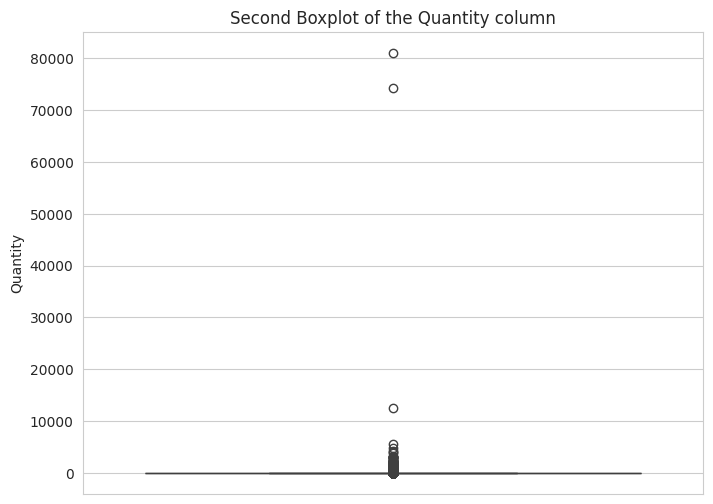

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y='Quantity', data=df)
plt.title("Second Boxplot of the Quantity column")
plt.show()

In [ ]:
df['Quantity'].describe()

count    541909.000000
mean         10.505183
std         155.289026
min           1.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [ ]:
Q1_Q = df['Quantity'].quantile(0.25)
Q2_Q = df['Quantity'].quantile(0.5)
Q3_Q = df['Quantity'].quantile(0.75)

lower_limit_Q = Q1_Q - 1.5 * (Q3_Q - Q1_Q)
upper_limit_Q = Q3_Q + 1.5 * (Q3_Q - Q1_Q)

print(f"Feature: Quantity")
print(f"- Q1: {Q1_Q:.2f}")
print(f"- Q2 (Mediana): {Q2_Q:.2f}")
print(f"- Q3: {Q3_Q:.2f}")
print(f"- Limite Inferior: {lower_limit_Q:.2f}")
print(f"- Limite Superior: {upper_limit_Q:.2f}")

Feature: Quantity
- Q1: 1.00
- Q2 (Mediana): 3.00
- Q3: 10.00
- Limite Inferior: -12.50
- Limite Superior: 23.50


In [ ]:
mean_Q = df['Quantity'].mean()
median_Q = df['Quantity'].median()
mode_Q = df['Quantity'].mode()[0]
var_Q = df['Quantity'].var()
std_Q = df['Quantity'].std()

print(f"Feature: Quantity")
print(f"- mean: {mean_Q:.6f}")
print(f"- median: {median_Q:.6f}")
print(f"- mode: {mode_Q:.6f}")
print(f"- var: {var_Q:.6f}")
print(f"- std: {std_Q:.6f}")

Feature: Quantity
- mean: 10.505183
- median: 3.000000
- mode: 1.000000
- var: 24114.681744
- std: 155.289026


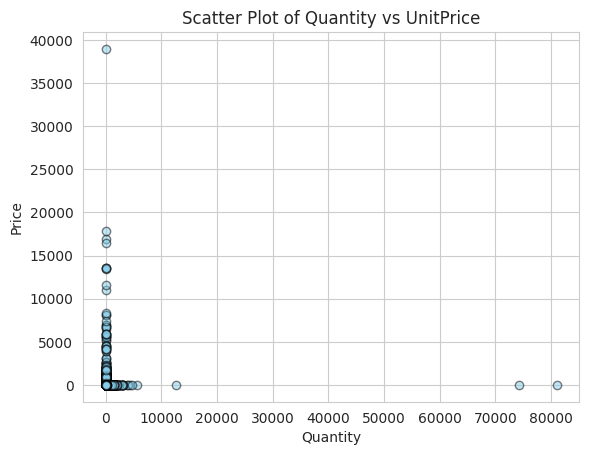

In [ ]:
plt.scatter(df['Quantity'], df['UnitPrice'], color='skyblue', edgecolor='black', alpha=0.5)
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.show()

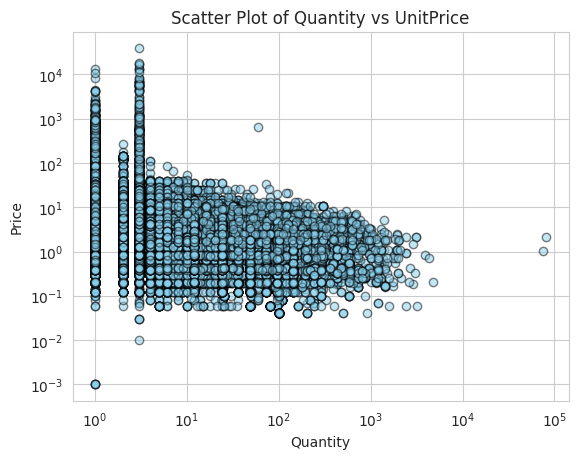

In [ ]:
plt.scatter(df['Quantity'], df['UnitPrice'], color='skyblue', edgecolor='black', alpha=0.5)
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.xlabel('Quantity')
plt.ylabel('Price')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
df['Country'].describe()

count             541909
unique                38
top       United Kingdom
freq              495478
Name: Country, dtype: object

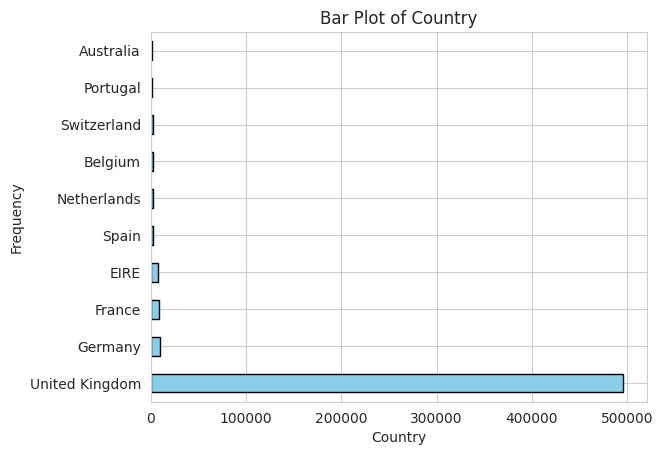

In [ ]:
df['Country'].value_counts().head(10).plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Bar Plot of Country')
plt.xlabel('Country')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['InvoiceDate'].describe()

count                        541909
mean     2011-07-04 13:34:57.156386
min             2010-12-01 08:26:00
25%             2011-03-28 11:34:00
50%             2011-07-19 17:17:00
75%             2011-10-19 11:27:00
max             2011-12-09 12:50:00
Name: InvoiceDate, dtype: object

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M')

df['Month'] = df['InvoiceDate'].dt.strftime('%m')
df['Week'] = df['InvoiceDate'].dt.strftime('%A')
df['Time'] = df['InvoiceDate'].dt.strftime('%H')

df = df.drop(columns=['InvoiceDate'])

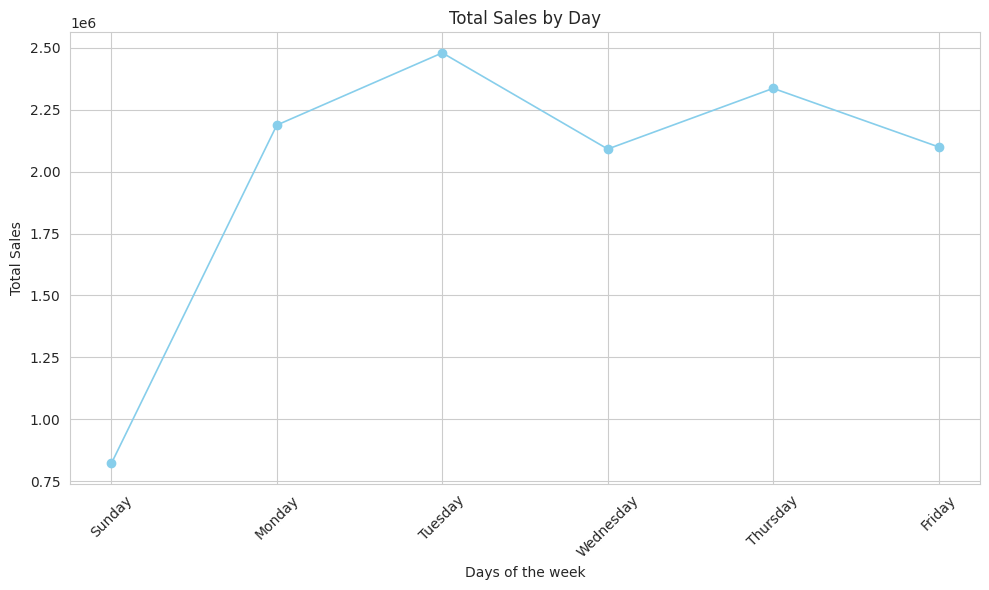

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
daywise = df.groupby('Week').agg({'TotalPrice': 'sum'}).reset_index()
df = df.drop(columns=['TotalPrice'])

daywise['Week'] = pd.Categorical(daywise['Week'], categories=["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"], ordered=True)
daywise = daywise.sort_values('Week')

plt.figure(figsize=(10, 6))
plt.plot(daywise['Week'], daywise['TotalPrice'], marker='o', color='skyblue', linewidth=1.2, markersize=6)
plt.title('Total Sales by Day')
plt.xlabel('Days of the week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

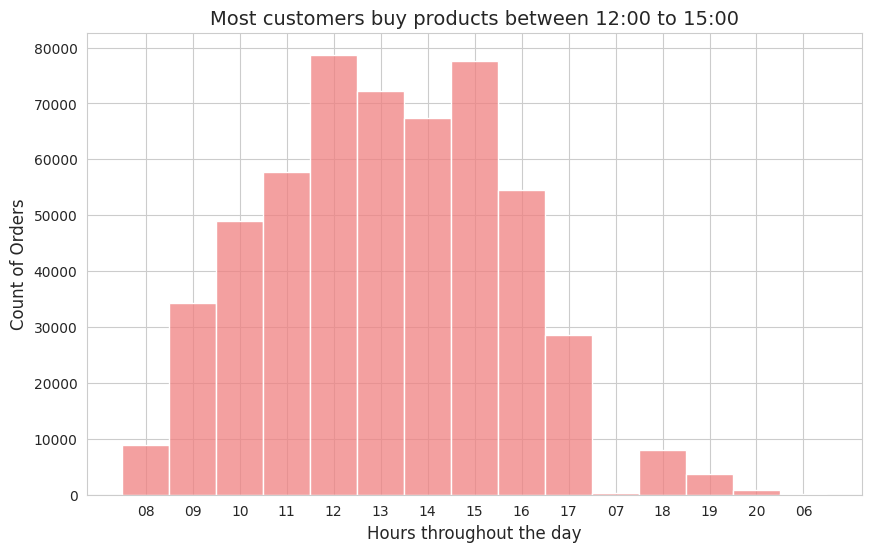

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Time', bins=24, color='lightcoral', kde=False)
plt.xlabel('Hours throughout the day', fontsize=12)
plt.ylabel('Count of Orders', fontsize=12)
plt.title('Most customers buy products between 12:00 to 15:00', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
plt.show()

In [ ]:
labels = [
    'January-February',
    'March-April',
    'May-June',
    'July-August',
    'September-October',
    'November-December'
]

df['Month'] = pd.cut(df['Month'].astype(int), bins=[0, 2, 4, 6, 8, 10, 12], labels=labels, right=True)

<Axes: title={'center': 'Months'}>

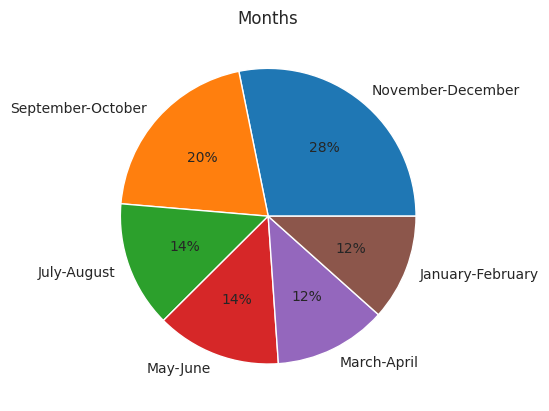

In [ ]:
df['Month'].value_counts().plot(kind='pie', autopct='%1.0f%%', title='Months')

In [ ]:
labels_time = ['Midnight', 'Morning', 'Afternoon', 'Night']
df['Time'] = pd.cut(df['Time'].astype(int), bins=[-1, 5, 11, 17, 24], labels=labels_time, right=True)

<Axes: title={'center': 'Shifts'}>

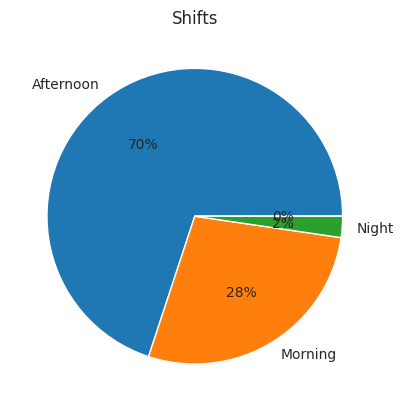

In [ ]:
df['Time'].value_counts().plot(kind='pie', autopct='%1.0f%%', title='Shifts')

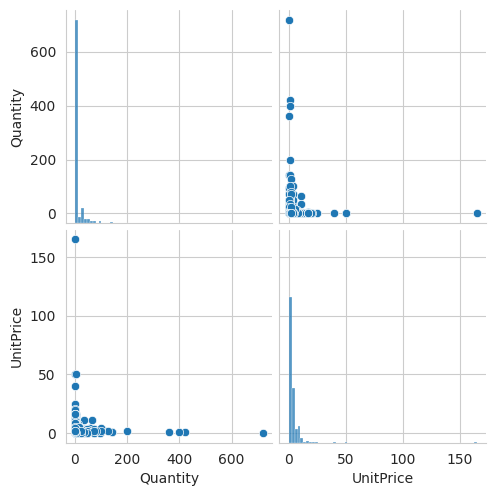

In [ ]:
df_numeric = df[['Quantity', 'UnitPrice']]
sns.pairplot(df_numeric.sample(1000))
plt.show()

In [ ]:
def categorize_price(price):
    if price <= Q1_UP:
        return "Low"
    elif price >= Q3_UP:
        return "High"
    else:
        return "Average"

df["PriceCategory"] = df["UnitPrice"].apply(categorize_price)

<Axes: title={'center': 'PriceCategory'}>

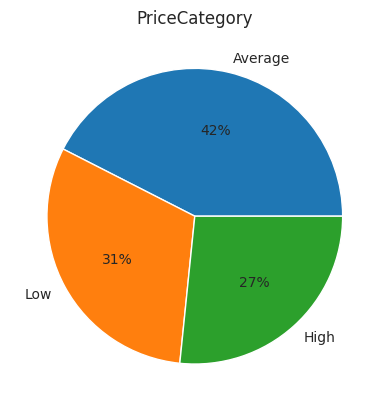

In [ ]:
df['PriceCategory'].value_counts().plot(kind='pie', autopct='%1.0f%%', title='PriceCategory')

In [ ]:
df = pd.get_dummies(df, columns=['Country', 'Month', 'Week', 'Time'])
df

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,PriceCategory,Country_Australia,Country_Austria,Country_Bahrain,...,Week_Friday,Week_Monday,Week_Sunday,Week_Thursday,Week_Tuesday,Week_Wednesday,Time_Midnight,Time_Morning,Time_Afternoon,Time_Night
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2.55,17850.0,Average,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,536365,71053,WHITE METAL LANTERN,6.0,3.39,17850.0,Average,False,False,False,...,False,False,False,False,False,True,False,True,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2.75,17850.0,Average,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,3.39,17850.0,Average,False,False,False,...,False,False,False,False,False,True,False,True,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,3.39,17850.0,Average,False,False,False,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12.0,0.85,12680.0,Low,False,False,False,...,True,False,False,False,False,False,False,False,True,False
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2.10,12680.0,Average,False,False,False,...,True,False,False,False,False,False,False,False,True,False
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,4.15,12680.0,High,False,False,False,...,True,False,False,False,False,False,False,False,True,False
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,4.15,12680.0,High,False,False,False,...,True,False,False,False,False,False,False,False,True,False


In [ ]:
x_temp = df.drop(['PriceCategory', 'InvoiceNo', 'CustomerID', 'Description', 'StockCode'], axis=1)

In [ ]:
le = LabelEncoder()
y = le.fit_transform(df['PriceCategory'])
class_names = le.classes_
print(f"Classes: {class_names}")

NameError: name 'LabelEncoder' is not defined

In [ ]:
x = x_temp.drop(['UnitPrice'], axis=1)
x = x.values

<Axes: title={'center': 'PriceCategory'}>

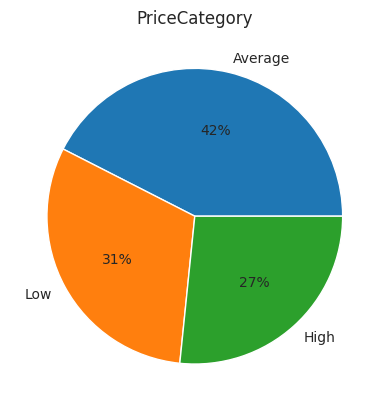

In [ ]:
y_temp.value_counts().plot(kind='pie', autopct='%1.0f%%', title='PriceCategory')

In [ ]:
# df_res = pd.DataFrame(x_temp_res, columns=x_temp.columns)

In [ ]:
df.shape

(541909, 61)

In [ ]:
scaler = StandardScaler()
X_escalonado = scaler.fit_transform(x)

In [ ]:
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_escalonado)
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Classe_Alvo'] = y

<Axes: xlabel='PC1', ylabel='PC2'>

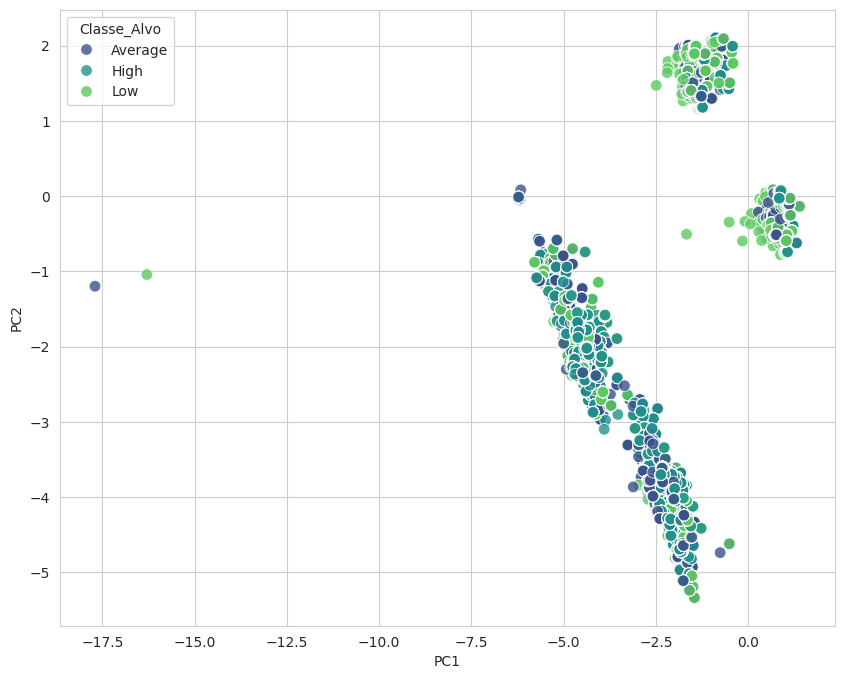

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Classe_Alvo', 
    palette='viridis',
    data=df_pca, 
    alpha=0.8,
    s=70
)

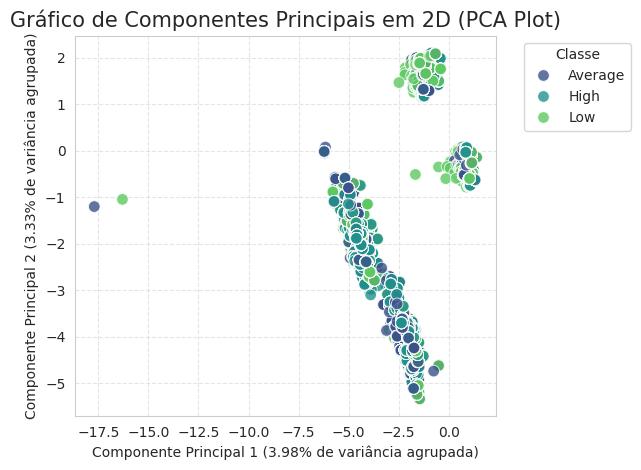

In [ ]:
sns.scatterplot(x='PC1', y='PC2', hue='Classe_Alvo', palette='viridis', data=df_pca, alpha=0.8, s=70)
expl_1 = pca.explained_variance_ratio_[0]*100
expl_2 = pca.explained_variance_ratio_[1]*100
plt.title('Gráfico de Componentes Principais em 2D (PCA Plot)', fontsize=15)
plt.xlabel(f"Componente Principal 1 ({expl_1:.2f}% de variância agrupada)")
plt.ylabel(f"Componente Principal 2 ({expl_2:.2f}% de variância agrupada)")
plt.legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

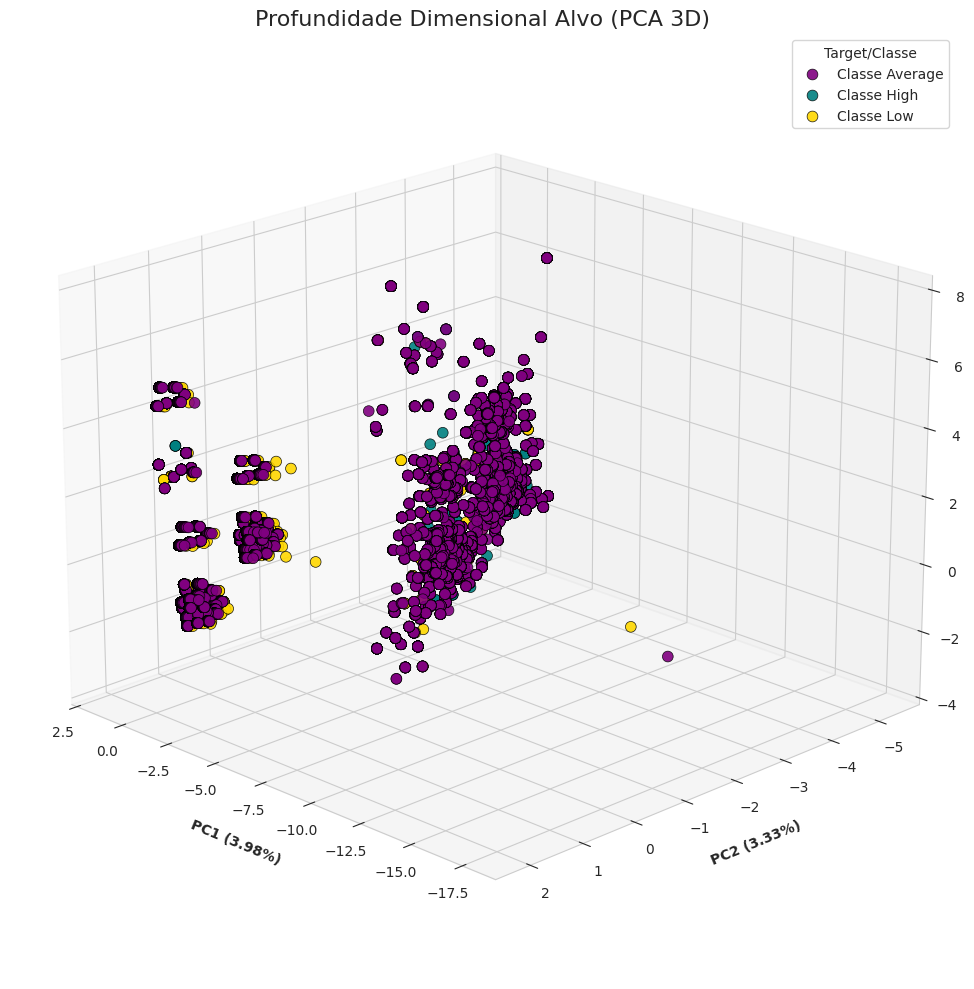

In [ ]:
pca_3d = PCA(n_components=3)
comps_3d = pca_3d.fit_transform(X_escalonado)
    
df_pca3 = pd.DataFrame(data=comps_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3['Classe_Alvo'] = y
    
# Matplotlib puro pro 3D 
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')

cores = ['purple', 'teal', 'gold'] 
classes_unicas = sorted(list(df_pca3['Classe_Alvo'].unique()))
    
# Plota classe por classe
for cls, cor in zip(classes_unicas, cores):
    subset = df_pca3[df_pca3['Classe_Alvo'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                color=cor, label=f'Classe {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)

e1_3d = pca_3d.explained_variance_ratio_[0]*100
e2_3d = pca_3d.explained_variance_ratio_[1]*100
e3_3d = pca_3d.explained_variance_ratio_[2]*100

ax.set_xlabel(f"PC1 ({e1_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_ylabel(f"PC2 ({e2_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_zlabel(f"PC3 ({e3_3d:.2f}%)", fontweight='bold', labelpad=10)
plt.title('Profundidade Dimensional Alvo (PCA 3D)', fontsize=16)
plt.legend(title='Target/Classe', loc='best')

# Opcional (rotacionar ângulo)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.show()

In [ ]:
param_grid_KNN = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'cosine']
}

In [ ]:
param_grid_DT = {
    'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

In [ ]:
param_grid_RF = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40, 50]
}

In [ ]:
param_grid_SVM = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.1],
    'probability': [True]
}

In [ ]:
param_grid_MLP = {
    'hidden_layer_sizes': [(32, 16), (64,)], 
     'alpha': [0.01, 0.1, 1.0],
     'learning_rate_init': [0.001], 
     'activation': ['relu', 'tanh'], 
     'solver': ['adam'], 
     'max_iter': [2000],
     'early_stopping': [True], 
     'random_state': [42],
}

In [ ]:
param_grid_LR = {
    'C': [0.01, 0.1, 1, 10],
     'solver': ['saga'],
     'penalty': ['l1', 'l2'],
}

In [ ]:
param_grid_XGB = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1, 1.0],
}

In [ ]:
param_grid_NB = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [ ]:
param_grid_NC = {
    'metric': ['euclidean', 'manhattan'],
    'shrink_threshold': [None, 0.1, 0.5, 1.0]
}

In [ ]:
param_grid_OPF = {
    'distance':['euclidean', 'squared_euclidean', 'log_squared_euclidean', 
                'manhattan', 'canberra', 'chebyshev']
}

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
S = MinMaxScaler()

In [ ]:
test_scores_KNN = []
acc_test_scores_KNN = []
precision_test_scores_KNN = []
recall_test_scores_KNN = []
f1_test_scores_KNN = []
auroc_test_scores_KNN = []

test_scores_DT = []
acc_test_scores_DT = []
precision_test_scores_DT = []
recall_test_scores_DT = []
f1_test_scores_DT = []
auroc_test_scores_DT = []

test_scores_RF = []
acc_test_scores_RF = []
precision_test_scores_RF = []
recall_test_scores_RF = []
f1_test_scores_RF = []
auroc_test_scores_RF = []

test_scores_SVM = []
acc_test_scores_SVM = []
precision_test_scores_SVM = []
recall_test_scores_SVM = []
f1_test_scores_SVM = []
auroc_test_scores_SVM = []

test_scores_MLP = []
acc_test_scores_MLP = []
precision_test_scores_MLP = []
recall_test_scores_MLP = []
f1_test_scores_MLP = []
auroc_test_scores_MLP = []

test_scores_LR = []
acc_test_scores_LR = []
precision_test_scores_LR = []
recall_test_scores_LR = []
f1_test_scores_LR = []
auroc_test_scores_LR = []

test_scores_XGB = []
acc_test_scores_XGB = []
precision_test_scores_XGB = []
recall_test_scores_XGB = []
f1_test_scores_XGB = []
auroc_test_scores_XGB = []

test_scores_NB = []
acc_test_scores_NB = []
precision_test_scores_NB = []
recall_test_scores_NB = []
f1_test_scores_NB = []
auroc_test_scores_NB = []

test_scores_NC = []
acc_test_scores_NC = []
precision_test_scores_NC = []
recall_test_scores_NC = []
f1_test_scores_NC = []
auroc_test_scores_NC = []

test_scores_OPF = []
acc_test_scores_OPF = []
precision_test_scores_OPF = []
recall_test_scores_OPF = []
f1_test_scores_OPF = []
auroc_test_scores_OPF = []

In [ ]:
confusion_matrices_KNN = []
confusion_matrices_DT = []
confusion_matrices_RF = []
confusion_matrices_SVM = []
confusion_matrices_MLP = []
confusion_matrices_LR = []
confusion_matrices_XGB = []
confusion_matrices_NB = []
confusion_matrices_NC = []
confusion_matrices_OPF = []

In [ ]:
resultados_mdi = {
    'DT': [], 'RF': [], 'XGB': [], 'OPF': []
}

In [ ]:
gridsearch_results_f1 = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [ ]:
gridsearch_results_acc = {
    'KNN': [], 'DT': [], 'RF': [], 'SVM': [],
    'MLP': [], 'LR': [], 'XGB': [], 'NB': [], 'NC': [], 'OPF': []
}

In [ ]:
for i, (train_index, test_index) in enumerate(kfold.split(x)):
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    y_train = y[train_index]

    nm = NearMiss()
    x_train, y_train = nm.fit_resample(x_train, y_train)

    x_train_D, x_val, y_train_D, y_val = train_test_split(x_train, y_train, test_size=0.2)

    params_KNN = []
    f1_val_KNN = []
    acc_val_KNN = []

    params_DT = []
    f1_val_DT = []
    acc_val_DT = []

    params_RF = []
    f1_val_RF = []
    acc_val_RF = []

    params_SVM = []
    f1_val_SVM = []
    acc_val_SVM = []

    params_MLP = []
    f1_val_MLP = []
    acc_val_MLP = []

    params_LR = []
    f1_val_LR = []
    acc_val_LR = []

    params_XGB = []
    f1_val_XGB = []
    acc_val_XGB = []

    params_NB = []
    f1_val_NB = []
    acc_val_NB = []

    params_NC = []
    f1_val_NC = []
    acc_val_NC = []

    params_OPF = []
    f1_val_OPF = []
    acc_val_OPF = []

    x_train_S = S.fit_transform(x_train)
    x_test_S = S.transform(x_test)


    x_train_D_S = S.fit_transform(x_train_D)
    x_val_S = S.transform(x_val)


    for params in ParameterGrid(param_grid_KNN):
        knn = KNeighborsClassifier(n_neighbors=params['n_neighbors'], metric=params['metric'])
        knn.fit(x_train_D_S, y_train_D)
        y_pred = knn.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_KNN.append(params)
        f1_val_KNN.append((y_val, y_pred))
        acc_val_KNN.append(acc)

    for params in ParameterGrid(param_grid_DT):
        dt = DecisionTreeClassifier(max_depth=params['max_depth'], random_state=42)
        dt.fit(x_train_D_S, y_train_D)
        y_pred = dt.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_DT.append(params)
        f1_val_DT.append((y_val, y_pred))
        acc_val_DT.append(acc)

    for params in ParameterGrid(param_grid_RF):
        rf = RandomForestClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
        rf.fit(x_train_D_S, y_train_D)
        y_pred = rf.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_RF.append(params)
        f1_val_RF.append((y_val, y_pred))
        acc_val_RF.append(acc)

    for params in ParameterGrid(param_grid_SVM):
        svm = SupportVectorMachineClassifier(C=params['C'], kernel=params['kernel'], probability=True, random_state=42)
        svm.fit(x_train_D_S, y_train_D)
        y_pred = svm.predict(x_val_S)
        acc = accuracy_score(y_val, y_pred)
        params_SVM.append(params)
        f1_val_SVM.append((y_val, y_pred))
        acc_val_SVM.append(acc)

    for params in ParameterGrid(param_grid_MLP):

      mlp = MLPClassifier(
          hidden_layer_sizes=params['hidden_layer_sizes'],
          alpha=params['alpha'],
          learning_rate_init=params['learning_rate_init'],
          activation=params['activation'],
          solver=params['solver'],
          max_iter=params['max_iter'],
          early_stopping=params['early_stopping'],
          random_state=params['random_state']
      )

      mlp.fit(x_train_D_S, y_train_D)
      y_pred = mlp.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_MLP.append(params)
      f1_val_MLP.append((y_val, y_pred))
      acc_val_MLP.append(acc)

    for params in ParameterGrid(param_grid_LR):
      lr = LogisticRegression(C=params['C'], solver='saga', max_iter=1000, random_state=42)
      lr.fit(x_train_D_S, y_train_D)
      y_pred = lr.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_LR.append(params)
      f1_val_LR.append((y_val, y_pred))
      acc_val_LR.append(acc)

    for params in ParameterGrid(param_grid_XGB):
      xgb = XGBClassifier(n_estimators=params['n_estimators'], max_depth=params['max_depth'], random_state=42)
      xgb.fit(x_train_D_S, y_train_D)
      y_pred = xgb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_XGB.append(params)
      f1_val_XGB.append((y_val, y_pred))
      acc_val_XGB.append(acc)

    for params in ParameterGrid(param_grid_NB):
      nb = GaussianNB(var_smoothing=params['var_smoothing'])
      nb.fit(x_train_D_S, y_train_D)
      y_pred = nb.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NB.append(params)
      f1_val_NB.append((y_val, y_pred))
      acc_val_NB.append(acc)

    for params in ParameterGrid(param_grid_NC):
      nc = NearestCentroid(metric=params['metric'], shrink_threshold=params['shrink_threshold'])
      nc.fit(x_train_D_S, y_train_D)
      y_pred = nc.predict(x_val_S)
      acc = accuracy_score(y_val, y_pred)
      params_NC.append(params)
      f1_val_NC.append((y_val, y_pred))
      acc_val_NC.append(acc)

    for params in ParameterGrid(param_grid_OPF):
      opf = SupervisedOPF(distance=params['distance'])
      opf.fit(np.array(x_train_D_S), np.array(y_train_D, dtype=np.int32))
      y_pred = opf.predict(np.array(x_val_S))
      acc = accuracy_score(y_val, y_pred)
      params_OPF.append(params)
      f1_val_OPF.append((y_val, y_pred))
      acc_val_OPF.append(acc)

    print(f"Fold {i+1}:")

    best_params_KNN = params_KNN[f1_val_KNN.index(max(f1_val_KNN))]
    best_params_DT  = params_DT[f1_val_DT.index(max(f1_val_DT))]
    best_params_RF  = params_RF[f1_val_RF.index(max(f1_val_RF))]
    best_params_SVM = params_SVM[f1_val_SVM.index(max(f1_val_SVM))]
    best_params_MLP = params_MLP[f1_val_MLP.index(max(f1_val_MLP))]
    best_params_LR  = params_LR[f1_val_LR.index(max(f1_val_LR))]
    best_params_XGB = params_XGB[f1_val_XGB.index(max(f1_val_XGB))]
    best_params_NB = params_NB[f1_val_NB.index(max(f1_val_NB))]
    best_params_NC = params_NC[f1_val_NC.index(max(f1_val_NC))]
    best_params_OPF = params_OPF[f1_val_OPF.index(max(f1_val_OPF))]


    gridsearch_results_f1['KNN'].append(max(f1_val_KNN))
    gridsearch_results_acc['KNN'].append(max(acc_val_KNN))

    gridsearch_results_f1['DT'].append(max(f1_val_DT))
    gridsearch_results_acc['DT'].append(max(acc_val_DT))  

    gridsearch_results_f1['RF'].append(max(f1_val_RF))
    gridsearch_results_acc['RF'].append(max(acc_val_RF))  

    gridsearch_results_f1['SVM'].append(max(f1_val_SVM))
    gridsearch_results_acc['SVM'].append(max(acc_val_SVM))

    gridsearch_results_f1['MLP'].append(max(f1_val_MLP))
    gridsearch_results_acc['MLP'].append(max(acc_val_MLP))

    gridsearch_results_f1['LR'].append(max(f1_val_LR))
    gridsearch_results_acc['LR'].append(max(acc_val_LR))  

    gridsearch_results_f1['XGB'].append(max(f1_val_XGB))
    gridsearch_results_acc['XGB'].append(max(acc_val_XGB))

    gridsearch_results_f1['NB'].append(max(f1_val_NB))
    gridsearch_results_acc['NB'].append(max(acc_val_NB))  

    gridsearch_results_f1['NC'].append(max(f1_val_NC))
    gridsearch_results_acc['NC'].append(max(acc_val_NC))

    gridsearch_results_f1['OPF'].append(max(f1_val_OPF))
    gridsearch_results_acc['OPF'].append(max(acc_val_OPF)) 


    knn = KNeighborsClassifier(n_neighbors=best_params_KNN['n_neighbors'], metric=best_params_KNN['metric'])
    knn.fit(x_train_S, y_train)
    y_pred_knn = knn.predict(x_test_S)
    knn_acc = accuracy_score(y_test, y_pred_knn)
    knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
    knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
    knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')
    knn_auroc = roc_auc_score(y_test, y_pred_knn, average='weighted')

    cm_knn = confusion_matrix(y_test, y_pred_knn)
    confusion_matrices_KNN.append(cm_knn)

    acc_test_scores_KNN.append(knn_acc)
    precision_test_scores_KNN.append(knn_precision)
    recall_test_scores_KNN.append(knn_recall)
    f1_test_scores_KNN.append(knn_f1)
    auroc_test_scores_KNN.append(knn_auroc)

    print(f"\tKNeighborsClassifier:")
    print(f"\t- Melhor n_neighbors: {best_params_KNN['n_neighbors']}")
    print(f"\t- acuracia do teste: {knn_acc:.2f}")
    print(f"\t- Precision no teste: {knn_precision:.4f}")
    print(f"\t- Recall no teste: {knn_recall:.4f}")
    print(f"\t- F1 no teste: {knn_f1:.4f}")
    print(f"\t- AUROC no teste: {knn_auroc:.4f}")

    dt = DecisionTreeClassifier(max_depth=best_params_DT['max_depth'], random_state=42)
    dt.fit(x_train_S, y_train)
    y_pred_dt = dt.predict(x_test_S)
    dt_acc = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
    dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
    dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')
    dt_auroc = roc_auc_score(y_test, y_pred_dt, average='weighted')


    resultados_mdi['DT'].append(dt.feature_importances_)

    cm_dt = confusion_matrix(y_test, y_pred_dt)
    confusion_matrices_DT.append(cm_dt)

    acc_test_scores_DT.append(dt_acc)
    precision_test_scores_DT.append(dt_precision)
    recall_test_scores_DT.append(dt_recall)
    f1_test_scores_DT.append(dt_f1)
    auroc_test_scores_DT.append(dt_auroc)


    print(f"\n\tDecisionTreeClassifier:")
    print(f"\t- Melhor max_depth: {best_params_DT['max_depth']}")
    print(f"\t- acuracia do teste: {dt_acc:.2f}")
    print(f"\t- Precision no teste: {dt_precision:.4f}")
    print(f"\t- Recall no teste: {dt_recall:.4f}")
    print(f"\t- F1 no teste: {dt_f1:.4f}")
    print(f"\t- AUROC no teste: {dt_auroc:.4f}")

    rf = RandomForestClassifier(n_estimators=best_params_RF['n_estimators'], max_depth=best_params_RF['max_depth'], random_state=42)
    rf.fit(x_train_S, y_train)
    y_pred_rf = rf.predict(x_test_S)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
    rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
    rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
    rf_auroc = roc_auc_score(y_test, y_pred_rf, average='weighted')

    resultados_mdi['RF'].append(rf.feature_importances_)

    cm_rf = confusion_matrix(y_test, y_pred_rf)
    confusion_matrices_RF.append(cm_rf)

    acc_test_scores_RF.append(rf_acc)
    precision_test_scores_RF.append(rf_precision)
    recall_test_scores_RF.append(rf_recall)
    f1_test_scores_RF.append(rf_f1)
    auroc_test_scores_RF.append(rf_auroc)

    print(f"\n\tRandomForestClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_RF['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_RF['max_depth']}")
    print(f"\t- acuracia do teste: {rf_acc:.2f}")
    print(f"\t- Precision no teste: {rf_precision:.4f}")
    print(f"\t- Recall no teste: {rf_recall:.4f}")
    print(f"\t- F1 no teste: {rf_f1:.4f}")
    print(f"\t- AUROC no teste: {rf_auroc:.4f}")

    svm.fit(x_train_S, y_train)
    y_pred_svm = svm.predict(x_test_S)
    svm_acc = accuracy_score(y_test, y_pred_svm)
    svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
    svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
    svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
    svm_auroc = roc_auc_score(y_test, y_pred_svm, average='weighted')

    cm_svm = confusion_matrix(y_test, y_pred_svm)
    confusion_matrices_SVM.append(cm_svm)

    acc_test_scores_SVM.append(svm_acc)
    precision_test_scores_SVM.append(svm_precision)
    recall_test_scores_SVM.append(svm_recall)
    f1_test_scores_SVM.append(svm_f1)
    auroc_test_scores_SVM.append(svm_auroc)

    print(f"\n\tSVM:")
    print(f"\t- Melhor C: {best_params_SVM['C']}")
    print(f"\t- Melhor kernel: {best_params_SVM['kernel']}")
    print(f"\t- acuracia do teste: {svm_acc:.2f}")
    print(f"\t- Precision no teste: {svm_precision:.4f}")
    print(f"\t- Recall no teste: {svm_recall:.4f}")
    print(f"\t- F1 no teste: {svm_f1:.4f}")
    print(f"\t- AUROC no teste: {svm_auroc:.4f}")

    mlp = MLPClassifier(**best_params_MLP)
    mlp.fit(x_train_S, y_train)
    y_pred_mlp = mlp.predict(x_test_S)
    mlp_acc = accuracy_score(y_test, y_pred_mlp)
    mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')
    mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')
    mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')
    mlp_auroc = roc_auc_score(y_test, y_pred_mlp, average='weighted')

    cm_mlp = confusion_matrix(y_test, y_pred_mlp)
    confusion_matrices_MLP.append(cm_mlp)

    acc_test_scores_MLP.append(mlp_acc)
    precision_test_scores_MLP.append(mlp_precision)
    recall_test_scores_MLP.append(mlp_recall)
    f1_test_scores_MLP.append(mlp_f1)
    auroc_test_scores_MLP.append(mlp_auroc)

    print(f"\n\tMLPClassifier:")
    print(f"\t- Melhor hidden_layer_sizes: {best_params_MLP['hidden_layer_sizes']}")
    print(f"\t- Melhor alpha: {best_params_MLP['alpha']}")
    print(f"\t- Melhor learning_rate_init: {best_params_MLP['learning_rate_init']}")
    print(f"\t- Acurácia no teste: {mlp_acc:.4f}")
    print(f"\t- Precision no teste: {mlp_precision:.4f}")
    print(f"\t- Recall no teste: {mlp_recall:.4f}")
    print(f"\t- F1 no teste: {mlp_f1:.4f}")
    print(f"\t- AUROC no teste: {mlp_auroc:.4f}")


    lr = LogisticRegression(**best_params_LR)
    lr.fit(x_train_S, y_train)
    y_pred_lr = lr.predict(x_test_S)
    lr_acc = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
    lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
    lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
    lr_auroc = roc_auc_score(y_test, y_pred_lr, average='weighted')

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    confusion_matrices_LR.append(cm_lr)

    acc_test_scores_LR.append(lr_acc)
    precision_test_scores_LR.append(lr_precision)
    recall_test_scores_LR.append(lr_recall)
    f1_test_scores_LR.append(lr_f1)
    auroc_test_scores_LR.append(lr_auroc)

    print(f"\n\tLogisticRegression:")
    print(f"\t- Melhor C: {best_params_LR['C']}")
    print(f"\t- Acurácia no teste: {lr_acc:.4f}")
    print(f"\t- Precision no teste: {lr_precision:.4f}")
    print(f"\t- Recall no teste: {lr_recall:.4f}")
    print(f"\t- F1 no teste: {lr_f1:.4f}")
    print(f"\t- AUROC no teste: {lr_auroc:.4f}")

    xgb = XGBClassifier(**best_params_XGB)
    xgb.fit(x_train_S, y_train)
    y_pred_xgb = xgb.predict(x_test_S)
    xgb_acc = accuracy_score(y_test, y_pred_xgb)
    xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted')
    xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted')
    xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
    xgb_auroc = roc_auc_score(y_test, y_pred_xgb, average='weighted')

    resultados_mdi['XGB'].append(xgb.feature_importances_)

    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    confusion_matrices_XGB.append(cm_xgb)

    acc_test_scores_XGB.append(xgb_acc)
    precision_test_scores_XGB.append(xgb_precision)
    recall_test_scores_XGB.append(xgb_recall)
    f1_test_scores_XGB.append(xgb_f1)
    auroc_test_scores_XGB.append(xgb_auroc)

    print(f"\n\tXGBClassifier:")
    print(f"\t- Melhor n_estimators: {best_params_XGB['n_estimators']}")
    print(f"\t- Melhor max_depth: {best_params_XGB['max_depth']}")
    print(f"\t- Acurácia no teste: {xgb_acc:.4f}")
    print(f"\t- Precision no teste: {xgb_precision:.4f}")
    print(f"\t- Recall no teste: {xgb_recall:.4f}")
    print(f"\t- F1 no teste: {xgb_f1:.4f}")
    print(f"\t- AUROC no teste: {xgb_auroc:.4f}")

    nb = GaussianNB(**best_params_NB)
    nb.fit(x_train_S, y_train)
    y_pred_nb = nb.predict(x_test_S)
    nb_acc = accuracy_score(y_test, y_pred_nb)
    nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
    nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
    nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
    nb_auroc = roc_auc_score(y_test, y_pred_nb, average='weighted')

    cm_nb = confusion_matrix(y_test, y_pred_nb)
    confusion_matrices_NB.append(cm_nb)

    acc_test_scores_NB.append(nb_acc)
    precision_test_scores_NB.append(nb_precision)
    recall_test_scores_NB.append(nb_recall)
    f1_test_scores_NB.append(nb_f1)
    auroc_test_scores_NB.append(nb_auroc)

    print(f"\n\tGaussianNB:")
    print(f"\t- Melhor var_smoothing: {best_params_NB['var_smoothing']}")
    print(f"\t- Acurácia no teste: {nb_acc:.4f}")
    print(f"\t- Precision no teste: {nb_precision:.4f}")
    print(f"\t- Recall no teste: {nb_recall:.4f}")
    print(f"\t- F1 no teste: {nb_f1:.4f}")
    print(f"\t- AUROC no teste: {nb_auroc:.4f}")

    nc = NearestCentroid(**best_params_NC)
    nc.fit(x_train_S, y_train)
    y_pred_nc = nc.predict(x_test_S)
    nc_acc = accuracy_score(y_test, y_pred_nc)
    nc_precision = precision_score(y_test, y_pred_nc, average='weighted')
    nc_recall = recall_score(y_test, y_pred_nc, average='weighted')
    nc_f1 = f1_score(y_test, y_pred_nc, average='weighted')
    nc_auroc = roc_auc_score(y_test, y_pred_nc, average='weighted')

    cm_nc = confusion_matrix(y_test, y_pred_nc)
    confusion_matrices_NC.append(cm_nc)

    acc_test_scores_NC.append(nc_acc)
    precision_test_scores_NC.append(nc_precision)
    recall_test_scores_NC.append(nc_recall)
    f1_test_scores_NC.append(nc_f1)
    auroc_test_scores_NC.append(nc_auroc)

    print(f"\n\tNearestCentroid:")
    print(f"\t- Melhor metric: {best_params_NC['metric']}")
    print(f"\t- Melhor shrink_threshold: {best_params_NC['shrink_threshold']}")
    print(f"\t- Acurácia no teste: {nc_acc:.4f}")
    print(f"\t- Precision no teste: {nc_precision:.4f}")
    print(f"\t- Recall no teste: {nc_recall:.4f}")
    print(f"\t- F1 no teste: {nc_f1:.4f}")
    print(f"\t- AUROC no teste: {nc_auroc:.4f}")

    opf = SupervisedOPF(**best_params_OPF)
    opf.fit(np.array(x_train_S), np.array(y_train, dtype=np.int32))
    y_pred_opf = opf.predict(np.array(x_test_S))
    opf_acc = accuracy_score(y_test, y_pred_opf)
    opf_precision = precision_score(y_test, y_pred_opf, average='weighted')
    opf_recall = recall_score(y_test, y_pred_opf, average='weighted')
    opf_f1 = f1_score(y_test, y_pred_opf, average='weighted')
    opf_auroc = roc_auc_score(y_test, y_pred_opf, average='weighted')

    cm_opf = confusion_matrix(y_test, y_pred_opf)
    confusion_matrices_OPF.append(cm_opf)

    acc_test_scores_OPF.append(opf_acc)
    precision_test_scores_OPF.append(opf_precision)
    recall_test_scores_OPF.append(opf_recall)
    f1_test_scores_OPF.append(opf_f1)
    auroc_test_scores_OPF.append(opf_auroc)

    print(f"\n\tSupervisedOPF:")
    print(f"\t- Melhor distance: {best_params_OPF['distance']}")
    print(f"\t- Acurácia no teste: {opf_acc:.4f}")
    print(f"\t- Precision no teste: {opf_precision:.4f}")
    print(f"\t- Recall no teste: {opf_recall:.4f}")
    print(f"\t- F1 no teste: {opf_f1:.4f}")
    print(f"\t- AUROC no teste: {opf_auroc:.4f}")

    print("----------------------------------------")

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
df_gs_acc = pd.DataFrame(gridsearch_results_acc, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_acc['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs_acc.columns:
    axes[0].plot(df_gs_acc.index, df_gs_acc[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor Acurácia de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs_acc.mean()
stds = df_gs_acc.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std da Acurácia (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Accuracy Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
df_gs = pd.DataFrame(gridsearch_results_f1, index=[f'Fold {i+1}' for i in range(len(gridsearch_results_f1['KNN']))])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Linhas por fold
for model in df_gs.columns:
    axes[0].plot(df_gs.index, df_gs[model], marker='o', label=model, linewidth=2)
axes[0].set_title('Melhor F1 de Validação por Fold (Grid Search)')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].set_ylim(0, 1)

# Barras com média ± std
means = df_gs.mean()
stds = df_gs.std()
bars = axes[1].bar(means.index, means.values, yerr=stds.values,
                   capsize=5, color=sns.color_palette("viridis", len(means)), alpha=0.85)
for bar, mean, std in zip(bars, means.values, stds.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
                 f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Média ± Std do F1 (Grid Search)')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('F1 Score Médio')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 16))  # altura maior para 3 linhas
models = ['KNN', 'Decision Tree', 'Random Forest', 'SVM', 'MLP', 'Logistic Regression', 'XGBoost', 'GaussianNB', 'NearestCentroid', 'SupervisedOPF']
confusion_matrices = [cm_knn, cm_dt, cm_rf, cm_svm, cm_mlp, cm_lr, cm_xgb, cm_nb, cm_nc, cm_opf]
colors = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples', 'Greys', 'YlOrBr', 'YlGnBu', 'BuPu', 'YlOrRd']

class_labels = [' 0-1 Visita ', ' 2+ Visitas ']

for j, (model, cm, color) in enumerate(zip(models, confusion_matrices, colors)):
    plt.subplot(3, 4, j+1)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap=color, ax=plt.gca(), values_format='d')

    plt.title(f'{model}', fontsize=12, fontweight='bold')
    plt.xlabel('Predição', fontsize=9)
    plt.ylabel('Real', fontsize=9)

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)

plt.suptitle(f'Matrizes de Confusão - Visitas Médicas (Fold {i+1})',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [ ]:
all_metrics_results = {
    'Acurácia': [
        ('KNeighborsClassifier', acc_test_scores_KNN),
        ('DecisionTreeClassifier', acc_test_scores_DT),
        ('RandomForestClassifier', acc_test_scores_RF),
        ('SVM', acc_test_scores_SVM),
        ('MLPClassifier', acc_test_scores_MLP),
        ('LogisticRegression', acc_test_scores_LR),
        ('XGBClassifier', acc_test_scores_XGB),
        ('GaussianNB', acc_test_scores_NB),
        ('NearestCentroid', acc_test_scores_NC),
        ('SupervisedOPF', acc_test_scores_OPF)
         
    ],
    'Precisão': [
        ('KNeighborsClassifier', precision_test_scores_KNN),
        ('DecisionTreeClassifier', precision_test_scores_DT),
        ('RandomForestClassifier', precision_test_scores_RF),
        ('SVM', precision_test_scores_SVM),
        ('MLPClassifier', precision_test_scores_MLP),
        ('LogisticRegression', precision_test_scores_LR),
        ('XGBClassifier', precision_test_scores_XGB),
        ('GaussianNB', precision_test_scores_NB),
        ('NearestCentroid', precision_test_scores_NC),
        ('SupervisedOPF', precision_test_scores_OPF)

    ],
    'Recall': [
        ('KNeighborsClassifier', recall_test_scores_KNN),
        ('DecisionTreeClassifier', recall_test_scores_DT),
        ('RandomForestClassifier', recall_test_scores_RF),
        ('SVM', recall_test_scores_SVM),
        ('MLPClassifier', recall_test_scores_MLP),
        ('LogisticRegression', recall_test_scores_LR),
        ('XGBClassifier', recall_test_scores_XGB),
        ('GaussianNB', recall_test_scores_NB),
        ('NearestCentroid', recall_test_scores_NC),
        ('SupervisedOPF', recall_test_scores_OPF)

    ],
    'F1-Score': [
        ('KNeighborsClassifier', f1_test_scores_KNN),
        ('DecisionTreeClassifier', f1_test_scores_DT),
        ('RandomForestClassifier', f1_test_scores_RF),
        ('SVM', f1_test_scores_SVM),
        ('MLPClassifier', f1_test_scores_MLP),
        ('LogisticRegression', f1_test_scores_LR),
        ('XGBClassifier', f1_test_scores_XGB),
        ('GaussianNB', f1_test_scores_NB),
        ('NearestCentroid', f1_test_scores_NC),
        ('SupervisedOPF', f1_test_scores_OPF)
    ],
    'AUROC': [
        ('KNeighborsClassifier', auroc_test_scores_KNN),
        ('DecisionTreeClassifier', auroc_test_scores_DT),
        ('RandomForestClassifier', auroc_test_scores_RF),
        ('SVM', auroc_test_scores_SVM),
        ('MLPClassifier', auroc_test_scores_MLP),
        ('LogisticRegression', auroc_test_scores_LR),
        ('XGBClassifier', auroc_test_scores_XGB),
        ('GaussianNB', auroc_test_scores_NB),
        ('NearestCentroid', auroc_test_scores_NC),
        ('SupervisedOPF', auroc_test_scores_OPF)
    ]
}

alpha = 0.05

for metric_name, model_scores_list in all_metrics_results.items():

    for i in range(len(model_scores_list)):
        for j in range(i + 1, len(model_scores_list)):
            model1_name, scores1 = model_scores_list[i]
            model2_name, scores2 = model_scores_list[j]

            print(f"\nComparando {model1_name} x {model2_name}:")

            if len(scores1) != len(scores2):
                print(f"\t- ERRO: Tamanhos das listas de scores são diferentes.")
                continue
            if len(scores1) < 2:
                print("\t- ERRO: Não há scores suficientes para o teste.")
                continue

            try:
                stat, p_val = wilcoxon(scores1, scores2, zero_method='zsplit', correction=False)
            except ValueError as e:
                print(f"\t- AVISO: Teste de Wilcoxon não pôde ser calculado. ({e})")
                mean1 = np.mean(scores1)
                mean2 = np.mean(scores2)
                print(f"\t- Média {model1_name}: {mean1:.4f}")
                print(f"\t- Média {model2_name}: {mean2:.4f}")
                print("\t-> Sem conclusão estatística.")
                print("----------------------------------------")
                continue

            mean1 = np.mean(scores1)
            mean2 = np.mean(scores2)

            print(f"\t- Amostras (n): {len(scores1)}")
            print(f"\t- Média {model1_name}: {mean1:.4f}")
            print(f"\t- Média {model2_name}: {mean2:.4f}")
            print(f"\t- Estatística Z: {stat:.4f}")
            print(f"\t- Valor-p (p-value): {p_val:.4f}")

            if p_val < alpha:
                print(f"\t-> Resultado: Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha}).")
                best_model = model1_name if mean1 > mean2 else model2_name
                print(f"\t-> Melhor modelo (pela média): {best_model}")
            else:
                print(f"\t-> Resultado: Sem diferença estatisticamente significativa (p >= {alpha}).")

            print("----------------------------------------")

In [ ]:
print("\nRESULTADOS FINAIS - MÉDIA ± DESVIO PADRÃO")

algorithms = {
    'KNeighborsClassifier':  (acc_test_scores_KNN, f1_test_scores_KNN, precision_test_scores_KNN, recall_test_scores_KNN, auroc_test_scores_KNN),
    'DecisionTreeClassifier':(acc_test_scores_DT,  f1_test_scores_DT,  precision_test_scores_DT,  recall_test_scores_DT,  auroc_test_scores_DT),
    'RandomForestClassifier':(acc_test_scores_RF,  f1_test_scores_RF,  precision_test_scores_RF,  recall_test_scores_RF,  auroc_test_scores_RF),
    'SVM':                   (acc_test_scores_SVM, f1_test_scores_SVM, precision_test_scores_SVM, recall_test_scores_SVM, auroc_test_scores_SVM),
    'MLPClassifier':         (acc_test_scores_MLP, f1_test_scores_MLP, precision_test_scores_MLP, recall_test_scores_MLP, auroc_test_scores_MLP),
    'LogisticRegression':    (acc_test_scores_LR,  f1_test_scores_LR,  precision_test_scores_LR,  recall_test_scores_LR,  auroc_test_scores_LR),
    'XGBClassifier':         (acc_test_scores_XGB, f1_test_scores_XGB, precision_test_scores_XGB, recall_test_scores_XGB, auroc_test_scores_XGB),
    'GaussianNB':           (acc_test_scores_NB,  f1_test_scores_NB,  precision_test_scores_NB,  recall_test_scores_NB,  auroc_test_scores_NB),
    'NearestCentroid':      (acc_test_scores_NC,  f1_test_scores_NC,  precision_test_scores_NC,  recall_test_scores_NC,  auroc_test_scores_NC),
    'SupervisedOPF':        (acc_test_scores_OPF, f1_test_scores_OPF, precision_test_scores_OPF, recall_test_scores_OPF, auroc_test_scores_OPF)
}

for name, (acc, f1, precision, recall, auroc) in algorithms.items():
    print(f"\n{name}:")
    print(f"  Acurácia : {np.mean(acc):.4f} ± {np.std(acc):.4f}")
    print(f"  F1       : {np.mean(f1):.4f} ± {np.std(f1):.4f}")
    print(f"  Precision: {np.mean(precision):.4f} ± {np.std(precision):.4f}")
    print(f"  Recall   : {np.mean(recall):.4f} ± {np.std(recall):.4f}")
    print(f"  AUROC    : {np.mean(auroc):.4f} ± {np.std(auroc):.4f}")

In [ ]:
test_scores_dict = [
    ('KNeighborsRegressor', test_scores_KNN),
    ('DecisionTreeRegressor', test_scores_DT),
    ('LinearRegression', test_scores_LR),
    ('RandomForestRegressor', test_scores_RF),
]

for i in range(len(test_scores_dict)):
    for j in range(i + 1, len(test_scores_dict)):
        model1, test_scores_1 = test_scores_dict[i]
        model2, test_scores_2 = test_scores_dict[j]

        print(f"\n{model1} e {model2}:")

        z, p = wilcoxon(test_scores_1, test_scores_2)

        print(f"\t- Estatística Z: {z}")
        print(f"\t- Valor-p: {p:.2f}")

        if p < 0.05:
            print("Diferença significativa (rejeitar H0).")

            mean1 = np.mean(test_scores_1)
            mean2 = np.mean(test_scores_2)

            best_model = model1 if mean1 < mean2 else model2
            print(f"{best_model} é o melhor modelo.")
        else:
            print("Sem diferença significativa (não rejeitar H0).")

        print("----------------------------------------")